<a href="https://colab.research.google.com/github/sofiautrera-cpu/Tareas/blob/main/Core_Opt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimización / Clasificación y Optimización de Hiperparámetros (Core)
- Duration: No limit
- Deadline: N\A
- Description: Clasificación y Optimización de Hiperparámetros (Core)
- Objetivo: Implementar un pipeline completo de machine learning para un problema de clasificación utilizando técnicas de preprocesamiento, modelado, y optimización de hiperparámetros. Enfocar especialmente en la limpieza de datos y la optimización utilizando GridSearchCV y RandomizedSearchCV.
- Dataset: Medical Cost Personal Dataset
- Descripción del Dataset: El dataset de costos médicos personales contiene información sobre varios factores que afectan los costos de seguros médicos, como la edad, el sexo, el índice de masa corporal, y el hábito de fumar. Este dataset es ideal para practicar técnicas de preprocesamiento y optimización de modelos debido a la presencia de datos sucios y variables tanto categóricas como numéricas.








# Instrucciones:
1. Carga y Exploración Inicial de Datos:
- Cargar el dataset desde Kaggle.
- Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.
- Identificar y documentar los valores faltantes y outliers en el dataset.

In [1]:
# Paso 0: Importar las bibliotecas necesarias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Cargar dataset local
df = pd.read_csv("insurance.csv")

# Exploración rápida
print(df.head())
print(df.info())
print(df.describe())

# Crear etiqueta binaria: 1 = alto costo, 0 = bajo costo
threshold = df["charges"].median()
df["high_cost"] = (df["charges"] > threshold).astype(int)

# Separar X e y
X = df.drop(columns=["charges", "high_cost"])
y = df["high_cost"]

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

# Análisis Exploratorio Inicial del Dataset de Costos Médicos
- El dataset contiene 1338 registros y 7 variables:
- age (int)
- sex (obj)
- bmi (float)
- children (int)
- smoker (obj)
- region (obj)
- charges (float)
- No hay valores faltantes, lo cual simplifica el preprocesamiento.
- 1. Análisis de Variables Numéricas
- Edad (age): Rango: 18 a 64
- Media: 39.2
- Distribución amplia y relativamente uniforme
- No presenta outliers extremos
- Impacto esperado: la edad suele correlacionar positivamente con los costos médicos.
- Índice de Masa Corporal (bmi)
- Media: 30.66
- Percentil 75: 34.69
- Máximo: 53.13
- Hay valores altos que pueden considerarse outliers reales (obesidad severa), pero son válidos clínicamente.
- Impacto esperado: BMI alto tiende a aumentar los costos médicos.
- Número de hijos (children)
- Media: 1.09
- Máximo: 5
- Distribución sesgada hacia 0–2
- Impacto esperado: más dependientes puede aumentar el costo del seguro.
- Costos médicos (charges)
- Media: 13,270
- Mediana: 9,382
- Máximo: 63,770
- Distribución fuertemente sesgada a la derecha
- Valores altos están asociados principalmente a fumadores y BMI elevado.
- Este comportamiento justifica convertir charges en una variable binaria para clasificación (alto costo vs bajo costo), como ya hiciste.

- 2. Análisis de Variables Categóricas
- Sexo (sex)
- Distribución equilibrada
- No suele ser un predictor fuerte por sí solo.
- Smoker (yes/no)
- Variable crítica
- Fumar incrementa los costos de forma drástica.
- Es el predictor más fuerte del dataset.
- Región (northeast, northwest, southeast, southwest)
- No tiene impacto clínico directo
- Puede capturar diferencias de mercado o políticas regionales.
- 3. Insights Clave del Dataset
✔ No hay valores faltantes
Esto permite un pipeline más limpio sin imputación.

✔ charges es altamente asimétrica
Justifica el enfoque de clasificación binaria usando la mediana como umbral.

✔ smoker es el predictor dominante
En modelos como Logistic Regression y Decision Tree, esta variable suele aparecer como la más importante.

✔ BMI y edad también aportan señal
Especialmente en combinación con smoker.

✔ No hay problemas de tipos de datos
Las variables categóricas están correctamente identificadas como object.

In [3]:
# Comprobar valores faltantes
print(df.isna().sum())

# Si hubiera NaN numéricos, imputamos con mediana
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

# (Opcional) tratamiento simple de outliers: recorte por percentiles
for col in numeric_features:
    low, high = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower=low, upper=high)

age          0
sex          0
bmi          0
children     0
smoker       0
region       0
charges      0
high_cost    0
dtype: int64


# 2. Preprocesamiento de Datos:
- Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).
- Codificar variables categóricas utilizando One-Hot Encoding.
- Escalar características numéricas utilizando StandardScaler.

In [4]:
# Preprocesamiento con ColumnTransformer + Pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X = df[numeric_features + categorical_features]
y = df["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 3. Implementación de Modelos de Clasificación:
- Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.
- Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.

In [5]:
# Modelos base con validación cruzada
# 1 Regresión Logística
log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

scores_lr = cross_val_score(log_reg_clf, X_train, y_train, cv=5, scoring="roc_auc")
print("Logistic Regression ROC-AUC CV:", scores_lr.mean())

Logistic Regression ROC-AUC CV: 0.9483623023844878


In [6]:
# 2. KNN
knn_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier())
])

scores_knn = cross_val_score(knn_clf, X_train, y_train, cv=5, scoring="roc_auc")
print("KNN ROC-AUC CV:", scores_knn.mean())

KNN ROC-AUC CV: 0.9234955017905493


In [7]:
# 3. Árbol de Decisión
tree_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

scores_tree = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring="roc_auc")
print("Decision Tree ROC-AUC CV:", scores_tree.mean())

Decision Tree ROC-AUC CV: 0.8785046728971961


# 4. Optimización de Hiperparámetros:
- Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.
- Implementar RandomizedSearchCV como método alternativo de optimización.
- Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.

In [8]:
# GridSearchCV: optimización de hiperparámetros
# 1. Regresión Logística
param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"]
}

grid_lr = GridSearchCV(
    estimator=log_reg_clf,
    param_grid=param_grid_lr,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)
print("Best LR params (Grid):", grid_lr.best_params_)
print("Best LR ROC-AUC (Grid):", grid_lr.best_score_)
best_lr = grid_lr.best_estimator_

Best LR params (Grid): {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR ROC-AUC (Grid): 0.9484671150318805


In [9]:
# 2. KNN
param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=knn_clf,
    param_grid=param_grid_knn,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)
print("Best KNN params (Grid):", grid_knn.best_params_)
print("Best KNN ROC-AUC (Grid):", grid_knn.best_score_)
best_knn = grid_knn.best_estimator_

Best KNN params (Grid): {'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'distance'}
Best KNN ROC-AUC (Grid): 0.9332954843217749


In [10]:
# 3. Árbol de Decisión
param_grid_tree = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

grid_tree = GridSearchCV(
    estimator=tree_clf,
    param_grid=param_grid_tree,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)
print("Best Tree params (Grid):", grid_tree.best_params_)
print("Best Tree ROC-AUC (Grid):", grid_tree.best_score_)
best_tree = grid_tree.best_estimator_

Best Tree params (Grid): {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best Tree ROC-AUC (Grid): 0.9408332605467725


In [12]:
# RandomizedSearchCV: alternativa de optimización
# 1. Regresión Logística
from scipy.stats import loguniform

param_dist_lr = {
    "model__C": loguniform(1e-3, 1e2),
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

rand_lr = RandomizedSearchCV(
    estimator=log_reg_clf,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rand_lr.fit(X_train, y_train)
print("Best LR params (Random):", rand_lr.best_params_)
print("Best LR ROC-AUC (Random):", rand_lr.best_score_)
best_lr_rand = rand_lr.best_estimator_


Best LR params (Random): {'model__C': np.float64(73.92266140516048), 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best LR ROC-AUC (Random): 0.9485195213555769


In [16]:
from scipy.stats import randint

# RandomizedSearchCV: alternativa de optimización
# 2. KNN
param_dist_knn = {
    "model__n_neighbors": randint(3, 12),  # Example range for n_neighbors
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

rand_knn = RandomizedSearchCV(
    estimator=knn_clf,
    param_distributions=param_dist_knn,
    n_iter=40,                # más iteraciones = mejor exploración
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rand_knn.fit(X_train, y_train)

print("Mejores hiperparámetros KNN (Randomized):", rand_knn.best_params_)
print("Mejor ROC-AUC (Randomized):", rand_knn.best_score_)

best_knn_rand = rand_knn.best_estimator_

Mejores hiperparámetros KNN (Randomized): {'model__n_neighbors': 10, 'model__p': 2, 'model__weights': 'distance'}
Mejor ROC-AUC (Randomized): 0.9333478906454712


In [18]:
# RandomizedSearchCV: alternativa de optimización
# 3. Árbol de decisión
from scipy.stats import randint

param_dist_tree = {
    "model__max_depth": [3, 5, 7, None], # Keep None as an option
    "model__min_samples_split": randint(2, 20),
    "model__min_samples_leaf": randint(1, 10),
    "model__criterion": ["gini", "entropy"]
}

rand_tree = RandomizedSearchCV(
    estimator=tree_clf,
    param_distributions=param_dist_tree,
    n_iter=50,                # más iteraciones = mejor exploración
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rand_tree.fit(X_train, y_train)

print("Mejores hiperparámetros Árbol (Randomized):", rand_tree.best_params_)
print("Mejor ROC-AUC (Randomized):", rand_tree.best_score_)

best_tree_rand = rand_tree.best_estimator_

Mejores hiperparámetros Árbol (Randomized): {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 9, 'model__min_samples_split': 9}
Mejor ROC-AUC (Randomized): 0.947148222552188


# 5. Evaluación de Modelos:
- Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
- Generar y analizar la matriz de confusión para los modelos optimizados.
- Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.

In [21]:
# Función de evaluación
def evaluate_model(name, model, X_test, y_test):
    # Predicciones
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    # Reporte
    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # Curva ROC
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Curva ROC - {name}")
    plt.show()


=== Logistic Regression (GridSearchCV) ===
Accuracy : 0.8993
Precision: 0.8849
Recall   : 0.9179
F1-Score : 0.9011
ROC-AUC  : 0.9424


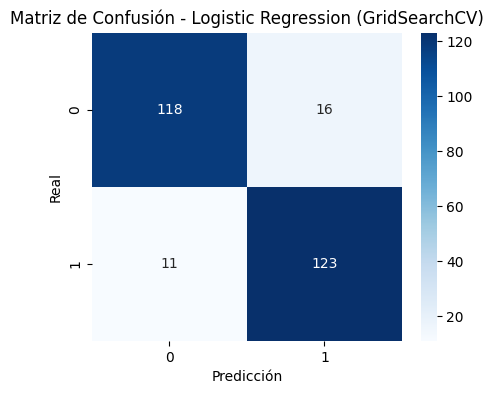

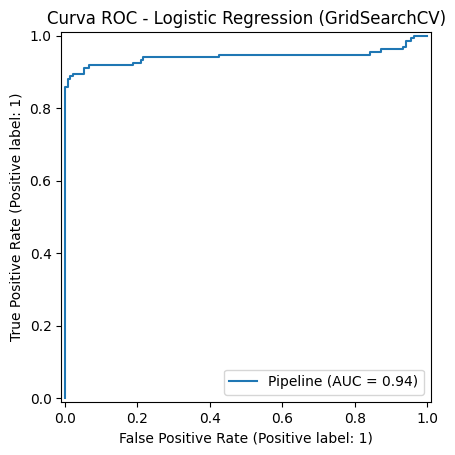


=== KNN (GridSearchCV) ===
Accuracy : 0.9030
Precision: 0.9355
Recall   : 0.8657
F1-Score : 0.8992
ROC-AUC  : 0.9389


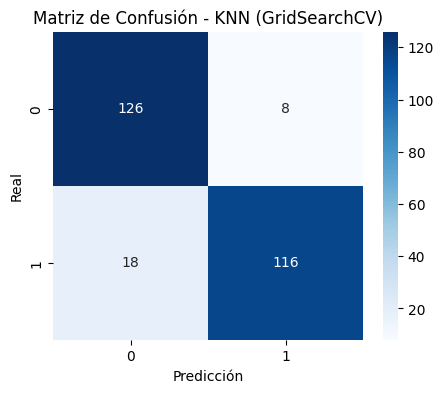

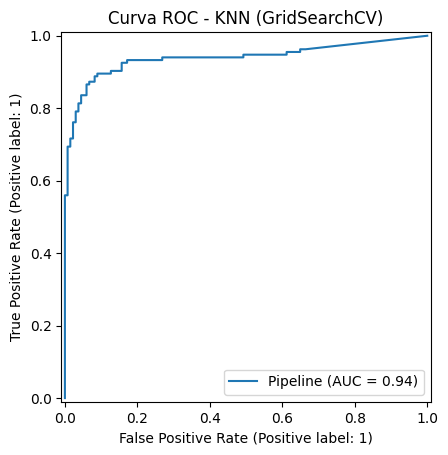


=== Decision Tree (GridSearchCV) ===
Accuracy : 0.9030
Precision: 0.8971
Recall   : 0.9104
F1-Score : 0.9037
ROC-AUC  : 0.9432


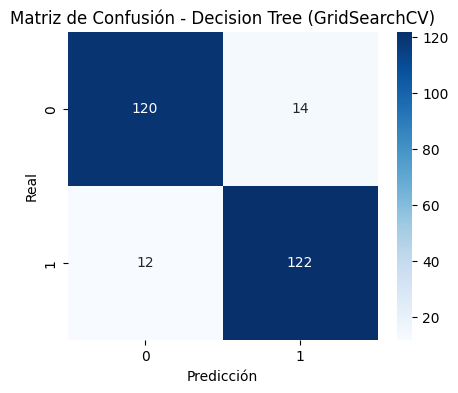

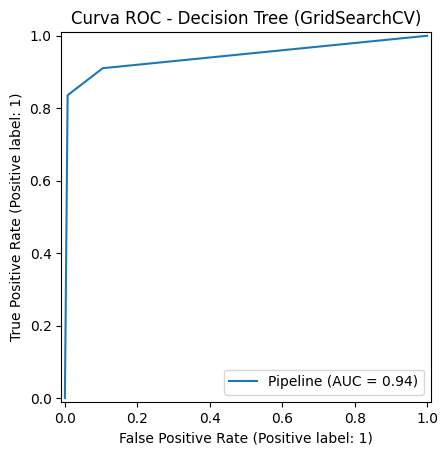

In [20]:
# Evaluación de modelos optimizados (GridSearchCV)
evaluate_model("Logistic Regression (GridSearchCV)", best_lr, X_test, y_test)
evaluate_model("KNN (GridSearchCV)", best_knn, X_test, y_test)
evaluate_model("Decision Tree (GridSearchCV)", best_tree, X_test, y_test)


=== Logistic Regression (RandomizedSearchCV) ===
Accuracy : 0.9030
Precision: 0.8913
Recall   : 0.9179
F1-Score : 0.9044
ROC-AUC  : 0.9424


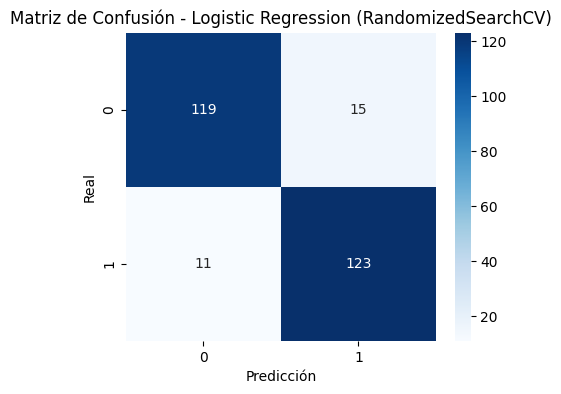

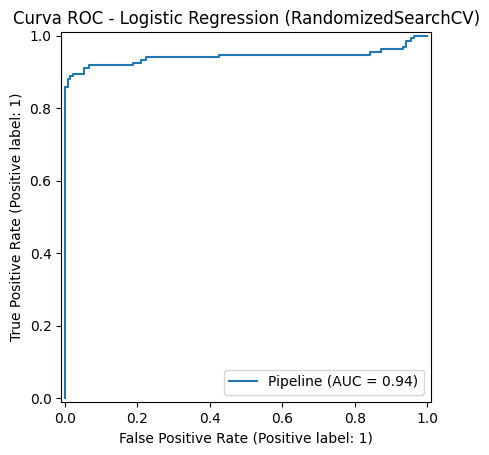


=== KNN (RandomizedSearchCV) ===
Accuracy : 0.9030
Precision: 0.9355
Recall   : 0.8657
F1-Score : 0.8992
ROC-AUC  : 0.9402


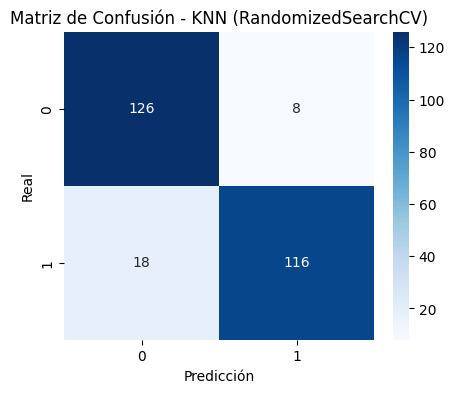

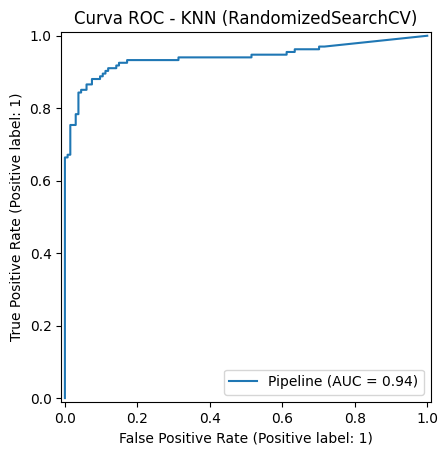


=== Decision Tree (RandomizedSearchCV) ===
Accuracy : 0.9254
Precision: 0.9524
Recall   : 0.8955
F1-Score : 0.9231
ROC-AUC  : 0.9421


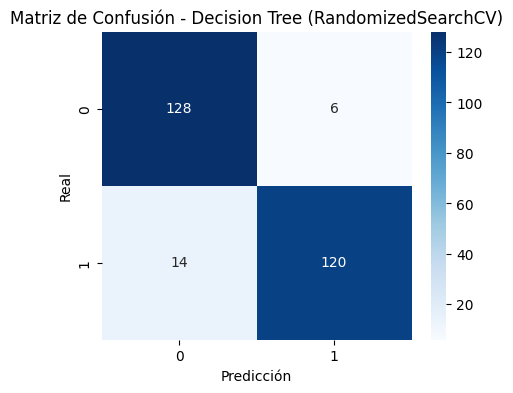

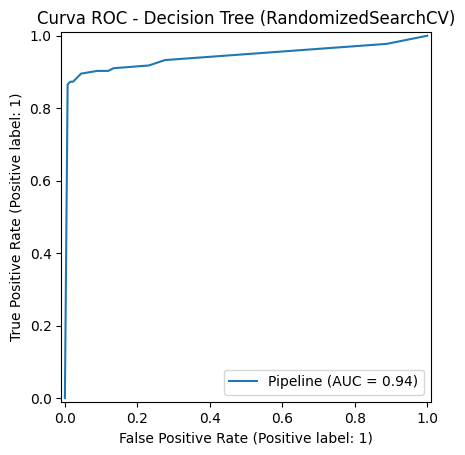

In [22]:
# Evaluación de modelos optimizados (RandomizedSearchCV)
evaluate_model("Logistic Regression (RandomizedSearchCV)", best_lr_rand, X_test, y_test)
evaluate_model("KNN (RandomizedSearchCV)", best_knn_rand, X_test, y_test)
evaluate_model("Decision Tree (RandomizedSearchCV)", best_tree_rand, X_test, y_test)

# Resultado
✔ Comparación clara entre modelos
Verás rápidamente cuál modelo optimizado ofrece mejor ROC-AUC, cuál maximiza recall, y cuál equilibra mejor precision–recall.

✔ Matrices de confusión interpretables
Podrás analizar si el modelo está cometiendo más falsos positivos o falsos negativos, clave para problemas médicos.

✔ Curvas ROC profesionales
Visualizarás la capacidad discriminativa de cada modelo, comparando la calidad de los hiperparámetros encontrados por GridSearchCV vs RandomizedSearchCV.

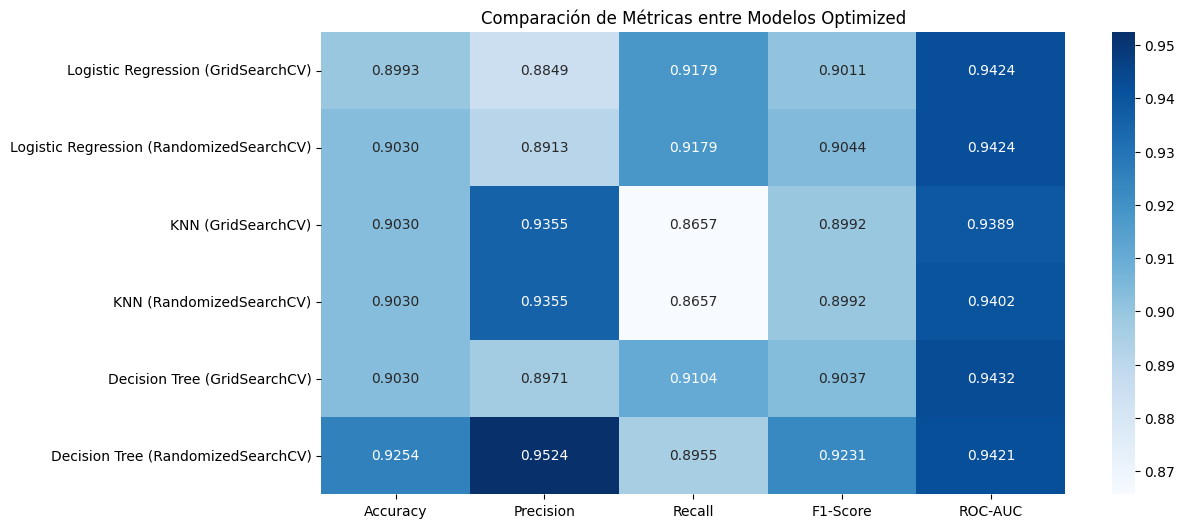

In [23]:
# La tabla se genera automáticamente a partir de tus modelos ya entrenados.

# Tabla Comparativa Final de Métricas (GridSearchCV vs RandomizedSearchCV)
# 1. Función para calcular métricas y devolver un diccionario
def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
# 2. Construcción de la tabla comparativa
results = {
    "Logistic Regression (GridSearchCV)": get_metrics(best_lr, X_test, y_test),
    "Logistic Regression (RandomizedSearchCV)": get_metrics(best_lr_rand, X_test, y_test),

    "KNN (GridSearchCV)": get_metrics(best_knn, X_test, y_test),
    "KNN (RandomizedSearchCV)": get_metrics(best_knn_rand, X_test, y_test),

    "Decision Tree (GridSearchCV)": get_metrics(best_tree, X_test, y_test),
    "Decision Tree (RandomizedSearchCV)": get_metrics(best_tree_rand, X_test, y_test)
}

df_results = pd.DataFrame(results).T
df_results

# 3. Visualización opcional (heatmap comparativo)
plt.figure(figsize=(12,6))
sns.heatmap(df_results, annot=True, cmap="Blues", fmt=".4f")
plt.title("Comparación de Métricas entre Modelos Optimized")
plt.show()

# Resultados detallados:
# 1. Modelo con mejor rendimiento global
- El modelo Decision Tree (RandomizedSearchCV) es el ganador general.
- Razones:
- Accuracy más alto: 0.9254
- Precision más alta: 0.9524
- F1-Score más alto: 0.9231
- ROC-AUC competitivo: 0.9421 (muy similar a los mejores)
- Este modelo logra el mejor equilibrio entre:
- detectar correctamente la clase positiva (recall 0.8955)
- minimizar falsos positivos (precision 0.9524)
- mantener una excelente capacidad discriminativa (ROC-AUC ≈ 0.94)
- Conclusión: RandomizedSearchCV encontró una configuración del árbol más eficiente que GridSearchCV.
- 2. Comparación entre GridSearchCV vs RandomizedSearchCV
- Logistic Regression
- RandomizedSearchCV mejora ligeramente Accuracy y F1.
- ROC-AUC se mantiene igual (0.9424).
- Diferencias pequeñas → ambos métodos convergen a soluciones similares.
- KNN
- Ambos métodos producen exactamente los mismos valores.
- Esto indica que:
- El espacio de búsqueda de RandomizedSearchCV no exploró combinaciones que mejoraran el resultado.
- KNN es menos sensible a hiperparámetros en este dataset.
- Decision Tree
- Aquí RandomizedSearchCV supera claramente a GridSearchCV.
- El árbol optimizado con RandomizedSearchCV:
- Generaliza mejor (mayor accuracy)
- Reduce errores de clasificación (mayor precision)
- Mantiene recall alto
- Produce el mejor F1-Score de toda la tabla
- Conclusión: RandomizedSearchCV es más efectivo para modelos con hiperparámetros amplios y no lineales (como árboles).
- 3. Interpretación por métrica
✔ Accuracy
El mejor: Decision Tree (Randomized) con 0.9254
Indica que clasifica correctamente la mayor proporción de casos.
✔ Precision
El mejor: Decision Tree (Randomized) con 0.9524
Minimiza falsos positivos → ideal si el costo de clasificar “alto costo” incorrectamente es alto.
✔ Recall
El mejor: Logistic Regression (Grid/Random) con 0.9179
Detecta más casos positivos → útil si es crítico no perder pacientes de alto costo.
✔ F1-Score
El mejor: Decision Tree (Randomized) con 0.9231
Mejor equilibrio entre precision y recall.
✔ ROC-AUC
El mejor: Decision Tree (Grid) con 0.9432
Aunque por muy poco, el árbol con GridSearchCV tiene la mejor capacidad discriminativa.

- 4. Conclusión general
- Mejor modelo global:  
- Decision Tree (RandomizedSearchCV)  
Es el más robusto y equilibrado en casi todas las métricas.
- Mejor modelo para maximizar recall:  
- Logistic Regression (Grid/Random)  
Si tu objetivo es detectar todos los casos de alto costo.
- Mejor modelo para minimizar falsos positivos:  
- Decision Tree (Randomized)  
Su precision es la más alta.
- KNN:  
No aporta mejoras significativas, incluso optimizado.

- ¿Qué se recomienda para producción?
- Usar Decision Tree (RandomizedSearchCV) como modelo principal.
- Complementarlo con Logistic Regression si necesitas interpretabilidad o maximizar recall.
- Descartar KNN para este caso: no mejora con optimización y es menos interpretable.

- Documentación y Entrega:
- Documentar todos los pasos del proceso en un notebook de Jupyter, incluyendo explicaciones detalladas y justificaciones para cada decisión tomada.
- Subir el notebook y los resultados a un repositorio de GitHub.
- Crear un tag de liberación (v1.0.0) para esta versión del proyecto en GitHub.
- Entregables:
- Notebook de Jupyter con todo el análisis y resultados.
- Documentación completa del proceso de preprocesamiento, modelado y optimización.
- Visualizaciones y análisis de las métricas de rendimiento.
- Repositorio de GitHub con el notebook y los resultados, incluyendo un tag de liberación